In [1]:
# ============================================================
# DAY 3 — Linear Models: Regression & Classification
# ACM SIGAI ML Recruitment | Week 1
# ============================================================

# ── Block 1: Imports ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)
print("All imports successful ✅")

# ── Block 2: Load & Explore Data ──────────────────────────
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target
print("Shape:", df.shape)
df.head()

# ── Block 3: Split & Scale ────────────────────────────────
X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Scaling done ✅")

# ── Block 4: Linear Regression ───────────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("📊 Linear Regression Results:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.3f}")

# ── Block 5: Ridge Regression ────────────────────────────
for alpha in [0.001, 1.0, 100.0, 1000.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    print(f"Alpha: {alpha:<10} R²: {r2_score(y_test, y_pred):.4f}")

# ── Block 6: Logistic Regression (Classification) ────────
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_c = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_c = pd.Series(cancer.target)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42)
scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_c, y_train_c)
y_pred_c = log_reg.predict(X_test_c)
print("📊 Logistic Regression Results:")
print(f"Accuracy:  {accuracy_score(y_test_c, y_pred_c):.3f}")
print(f"F1 Score:  {f1_score(y_test_c, y_pred_c):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_c, y_pred_c):.3f}")
print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_c))
print("\n📊 Full Report:")
print(classification_report(y_test_c, y_pred_c))

All imports successful ✅
Shape: (20640, 9)
Training samples: 16512
Testing samples: 4128
Scaling done ✅
📊 Linear Regression Results:
MAE:  0.533
RMSE: 0.746
R²:   0.576
Alpha: 0.001      R²: 0.5758
Alpha: 1.0        R²: 0.5758
Alpha: 100.0      R²: 0.5778
Alpha: 1000.0     R²: 0.5681
📊 Logistic Regression Results:
Accuracy:  0.974
F1 Score:  0.979
ROC-AUC:   0.970

📊 Confusion Matrix:
[[41  2]
 [ 1 70]]

📊 Full Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Imports done ✅
Shape: (20640, 9)
New features added ✅
   rooms_per_household  bedrooms_per_room  population_per_household
0             2.732919           0.146591                     126.0
1             2.956685           0.155797                    1138.0
2             2.957661           0.129516                     177.0
3             2.283154           0.184458                     219.0
4             2.879646           0.172096                     259.0


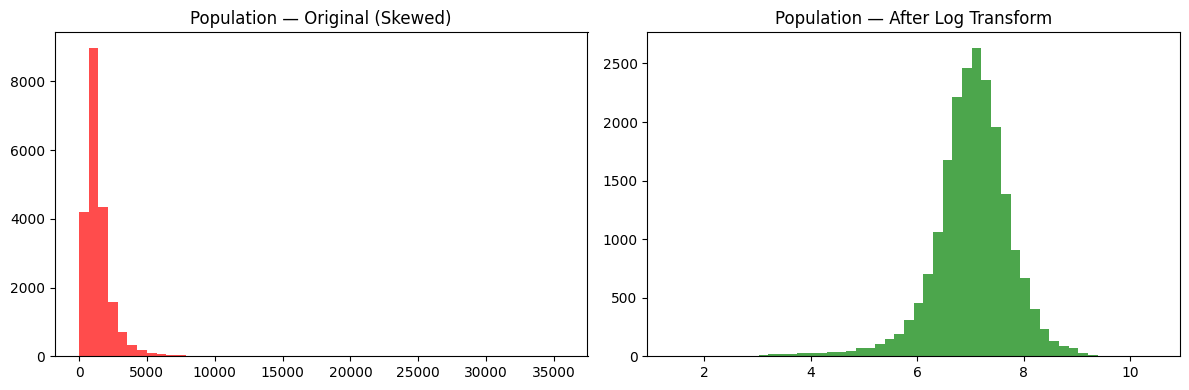

Original shape: (20640, 1)
After polynomial: (20640, 2)


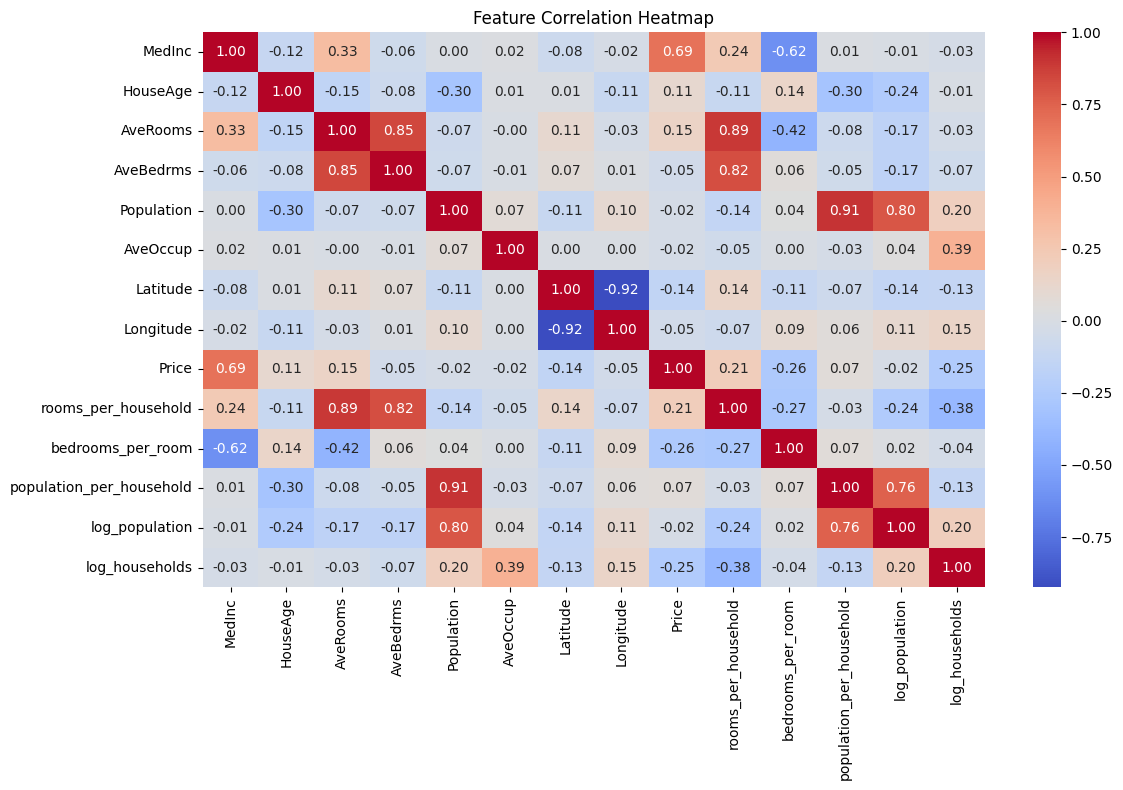


Correlation with Price:
Price                       1.000000
MedInc                      0.688075
rooms_per_household         0.209482
AveRooms                    0.151948
HouseAge                    0.105623
population_per_household    0.065843
log_population             -0.021205
AveOccup                   -0.023737
Population                 -0.024650
Longitude                  -0.045967
AveBedrms                  -0.046701
Latitude                   -0.144160
log_households             -0.247044
bedrooms_per_room          -0.255624
Name: Price, dtype: float64
Before SMOTE: {0: 10323, 1: 10317}
After SMOTE: {1: 10323, 0: 10323}


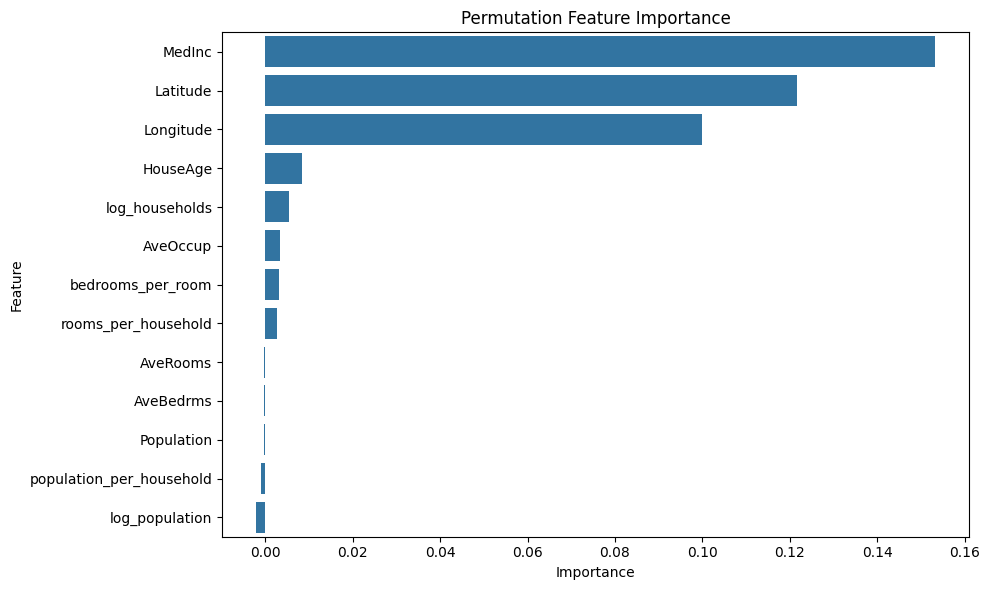

In [2]:
# ============================================================
# DAY 4 — Feature Engineering
# ACM SIGAI ML Recruitment | Week 1
# ============================================================

# ── Block 1: Imports ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
print("Imports done ✅")

# ── Block 2: Load Data ────────────────────────────────────
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target
print("Shape:", df.shape)

# ── Block 3: Interaction Features ─────────────────────────
df['rooms_per_household'] = df['AveRooms'] / df['AveOccup']
df['bedrooms_per_room'] = df['AveBedrms'] / df['AveRooms']
df['population_per_household'] = df['Population'] / df['AveOccup']
print("New features added ✅")
print(df[['rooms_per_household',
          'bedrooms_per_room',
          'population_per_household']].head())

# ── Block 4: Log Transform ────────────────────────────────
df['log_population'] = np.log1p(df['Population'])
df['log_households'] = np.log1p(df['AveOccup'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Population'], bins=50, color='red', alpha=0.7)
axes[0].set_title('Population — Original (Skewed)')
axes[1].hist(df['log_population'], bins=50, color='green', alpha=0.7)
axes[1].set_title('Population — After Log Transform')
plt.tight_layout()
plt.show()

# ── Block 5: Polynomial Features ──────────────────────────
X_income = df[['MedInc']].values
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_income)
print("Original shape:", X_income.shape)
print("After polynomial:", X_poly.shape)

# ── Block 6: Correlation Heatmap ──────────────────────────
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
print("\nCorrelation with Price:")
print(df.corr()['Price'].sort_values(ascending=False))

# ── Block 7: SMOTE for Class Imbalance ────────────────────
df['expensive'] = (df['Price'] > df['Price'].median()).astype(int)
X = df.drop(['Price', 'expensive'], axis=1)
y = df['expensive']
print("Before SMOTE:", y.value_counts().to_dict())
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

# ── Block 8: Permutation Importance ───────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
result = permutation_importance(rf, X_test_scaled, y_test,
                                n_repeats=10, random_state=42)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False)
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.show()

Imports done ✅
Data ready ✅ | Shape: (569, 30)
📊 Decision Tree:
Accuracy: 0.947
F1 Score: 0.958
ROC-AUC:  0.939


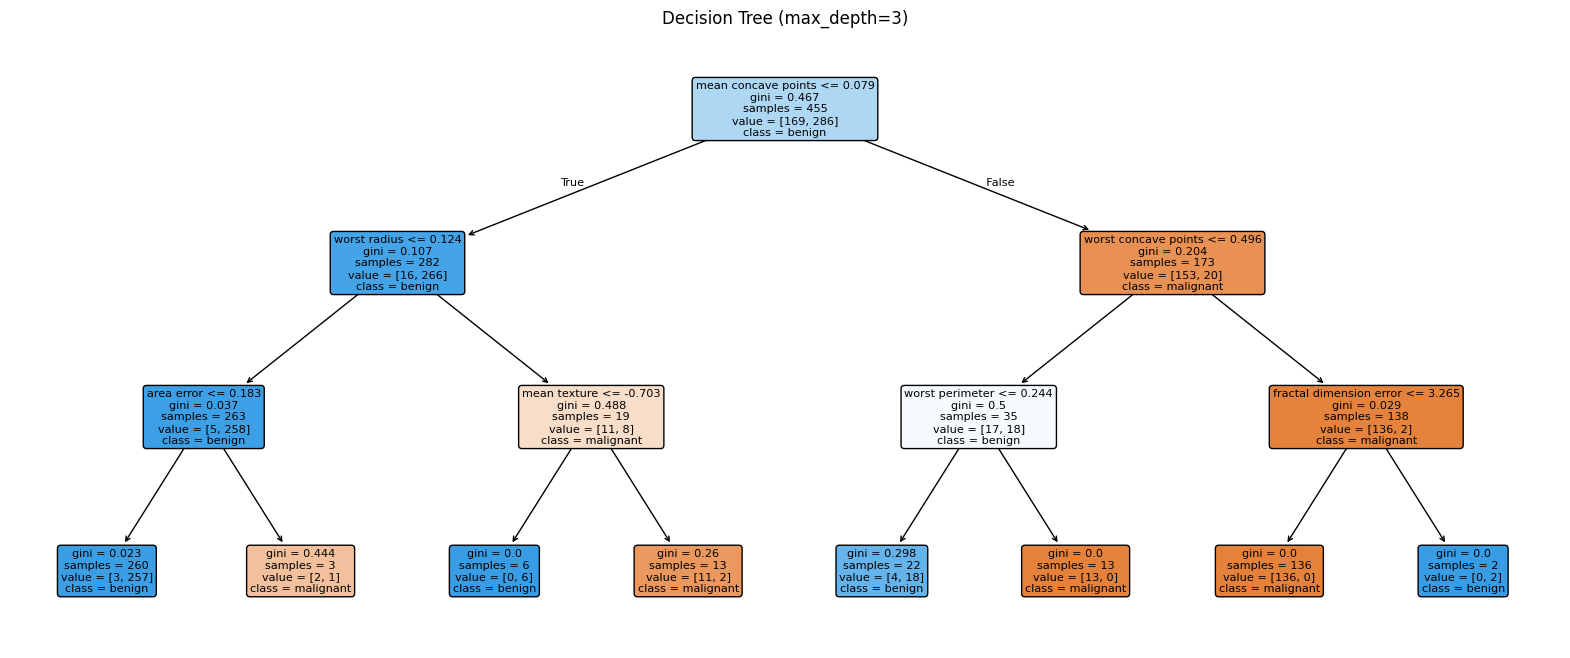

📊 Random Forest:
Accuracy: 0.965
F1 Score: 0.972
ROC-AUC:  0.958


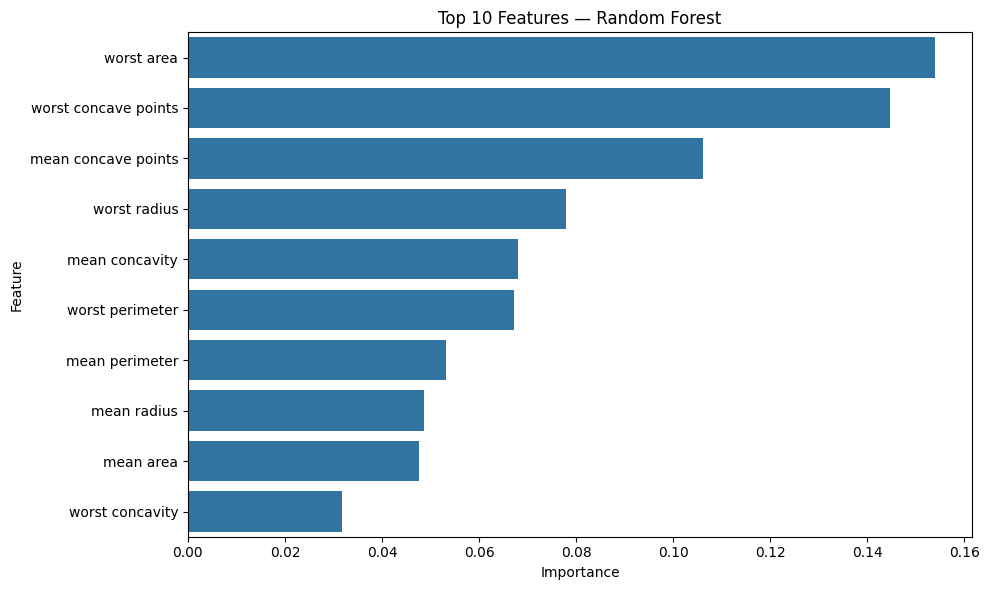

📊 XGBoost:
Accuracy: 0.965
F1 Score: 0.972
ROC-AUC:  0.958

📊 Model Comparison:
        Model  Accuracy  F1 Score  ROC-AUC
Decision Tree  0.947368  0.958333 0.939404
Random Forest  0.964912  0.972222 0.958074
      XGBoost  0.964912  0.972222 0.958074


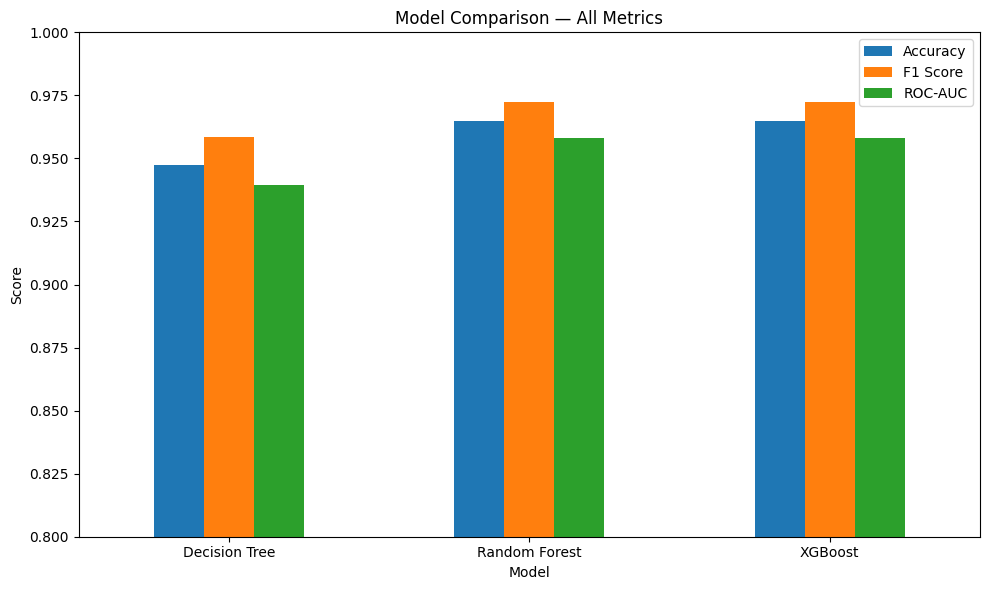

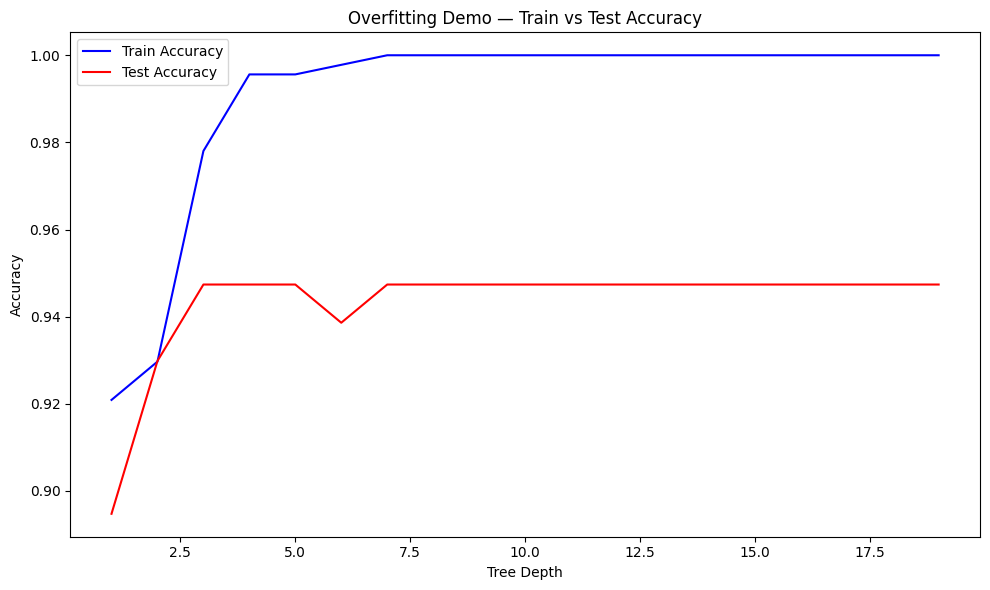

In [3]:
# ============================================================
# DAY 5 — Tree Models & Ensemble Methods
# ACM SIGAI ML Recruitment | Week 1
# ============================================================

# ── Block 1: Imports ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, classification_report)
print("Imports done ✅")

# ── Block 2: Load & Split Data ────────────────────────────
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data ready ✅ | Shape:", X.shape)

# ── Block 3: Decision Tree ────────────────────────────────
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print("📊 Decision Tree:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_dt):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_pred_dt):.3f}")
plt.figure(figsize=(20, 8))
plot_tree(dt, feature_names=cancer.feature_names,
          class_names=cancer.target_names, filled=True, rounded=True)
plt.title('Decision Tree (max_depth=3)')
plt.show()

# ── Block 4: Random Forest ────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("📊 Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_pred_rf):.3f}")
importance_df = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Top 10 Features — Random Forest')
plt.tight_layout()
plt.show()

# ── Block 5: XGBoost ──────────────────────────────────────
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='logloss', verbosity=0)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print("📊 XGBoost:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_pred_xgb):.3f}")

# ── Block 6: Model Comparison ─────────────────────────────
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_xgb)],
    'F1 Score': [f1_score(y_test, y_pred_dt),
                 f1_score(y_test, y_pred_rf),
                 f1_score(y_test, y_pred_xgb)],
    'ROC-AUC':  [roc_auc_score(y_test, y_pred_dt),
                 roc_auc_score(y_test, y_pred_rf),
                 roc_auc_score(y_test, y_pred_xgb)]
})
print("\n📊 Model Comparison:")
print(results.to_string(index=False))
results.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison — All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

# ── Block 7: Overfitting Demo ─────────────────────────────
train_scores, test_scores = [], []
depths = range(1, 20)
for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train,
                        dt_temp.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test,
                       dt_temp.predict(X_test_scaled)))
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Train Accuracy', color='blue')
plt.plot(depths, test_scores, label='Test Accuracy', color='red')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting Demo — Train vs Test Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Imports done ✅
📊 Cross-Validation Scores (5 folds): [0.96703297 0.95604396 0.93406593 0.96703297 0.98901099]
Mean Accuracy: 0.9626
Std Deviation: 0.0179
📊 Best alpha: {'alpha': 0.001}
📊 Best R²: 0.6114839952527685
📊 Best RF params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
📊 Best CV accuracy: 0.9604246543511096
📊 Test accuracy: 0.9473684210526315
📊 Best XGB params: {'learning_rate': np.float64(0.24555278841790407), 'max_depth': 5, 'n_estimators': 157, 'subsample': np.float64(0.8056937753654446)}
📊 Best CV accuracy: 0.964868711513884
📊 Test accuracy: 0.9649122807017544


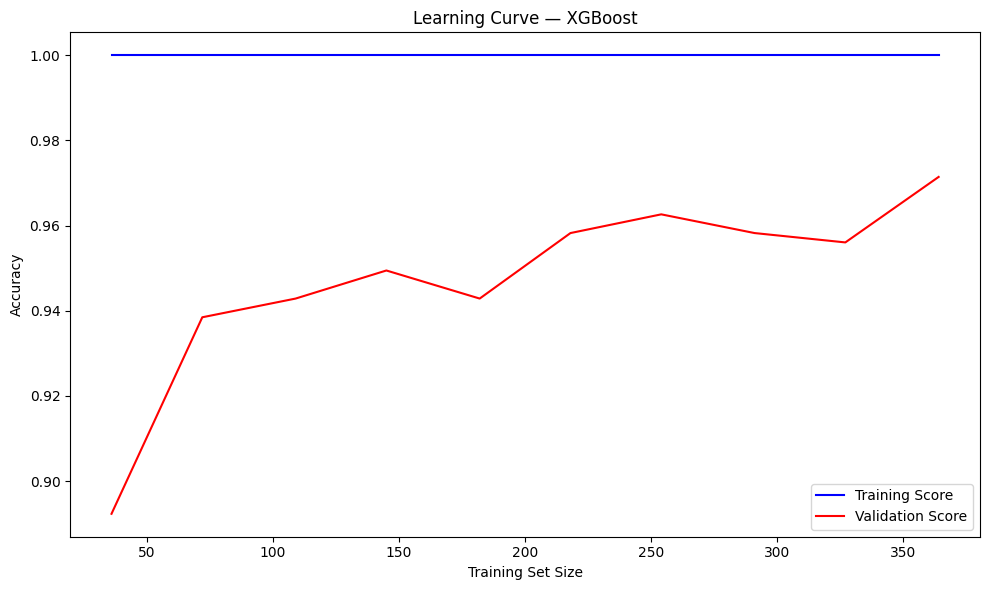

In [4]:
# ============================================================
# DAY 6 — Hyperparameter Tuning & Cross-Validation
# ACM SIGAI ML Recruitment | Week 1
# ============================================================

# ── Block 1: Imports ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
print("Imports done ✅")

# ── Block 2: k-Fold Cross Validation ─────────────────────
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_scaled, y_train,
                             cv=skf, scoring='accuracy')
print("📊 Cross-Validation Scores (5 folds):", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")

# ── Block 3: GridSearchCV on Ridge ────────────────────────
housing = fetch_california_housing()
X_h = pd.DataFrame(housing.data, columns=housing.feature_names)
y_h = pd.Series(housing.target)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42)
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
grid_search = GridSearchCV(Ridge(), param_grid, cv=5,
                            scoring='r2', n_jobs=-1)
grid_search.fit(X_train_h_scaled, y_train_h)
print("📊 Best alpha:", grid_search.best_params_)
print("📊 Best R²:", grid_search.best_score_)

# ── Block 4: GridSearchCV on Random Forest ────────────────
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=3, scoring='accuracy', n_jobs=1)
grid_search_rf.fit(X_train_scaled, y_train)
print("📊 Best RF params:", grid_search_rf.best_params_)
print("📊 Best CV accuracy:", grid_search_rf.best_score_)
best_rf = grid_search_rf.best_estimator_
print("📊 Test accuracy:", accuracy_score(y_test,
                           best_rf.predict(X_test_scaled)))

# ── Block 5: RandomizedSearchCV on XGBoost ────────────────
param_dist_xgb = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4)
}
random_search_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=param_dist_xgb,
    n_iter=10, cv=3, scoring='accuracy', n_jobs=1, random_state=42)
random_search_xgb.fit(X_train_scaled, y_train)
print("📊 Best XGB params:", random_search_xgb.best_params_)
print("📊 Best CV accuracy:", random_search_xgb.best_score_)
best_xgb = random_search_xgb.best_estimator_
print("📊 Test accuracy:", accuracy_score(y_test,
                           best_xgb.predict(X_test_scaled)))

# ── Block 6: Learning Curves ──────────────────────────────
train_sizes, train_scores, test_scores = learning_curve(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    X_train_scaled, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=1)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1),
         label='Training Score', color='blue')
plt.plot(train_sizes, test_scores.mean(axis=1),
         label='Validation Score', color='red')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve — XGBoost')
plt.legend()
plt.tight_layout()
plt.show()